# Worksheet 1 - Statistics & Spatial Statistics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import bootstrap

**Open data**

In [2]:
df_full = pd.read_csv('sdss_cutout.csv')
print(df_full)

                RA        DEC         Z     phot_u     phot_g     phot_r  \
0       130.089951  52.178097  0.097629  19.854843  18.159964  17.345013   
1       130.173909  52.557767  0.067737  19.250399  17.239248  16.517265   
2       130.081237  52.668188  0.063350  18.680342  17.206959  16.697826   
3       130.291706  52.572373  0.065425  19.726742  17.791235  16.906610   
4       130.013537  52.766588  0.123360  19.386818  17.534359  16.450377   
...            ...        ...       ...        ...        ...        ...   
319953  149.580633  47.033396  0.390038  23.223936  19.346468  17.534588   
319954  150.261929  46.827647  0.204686  20.360432  18.511255  17.276648   
319955  149.937963  46.482358  0.102099  19.087252  17.185118  16.237055   
319956  150.023597  46.260926  0.069142  19.072407  17.949339  17.497790   
319957  149.753111  46.454115  0.070916  18.535280  17.313433  16.803703   

           phot_i     phot_z  
0       16.930433  16.620535  
1       16.083832  15.822

**Task 1**

In [3]:
# cut redshift range: 0.08 < z < 0.12

df = df_full.drop(df_full[(df_full.Z < 0.08) | (df_full.Z > 0.12)].index)

Text(0.5, 1.0, 'eCDF of the redshift distribution for 0.08 < z < 0.12')

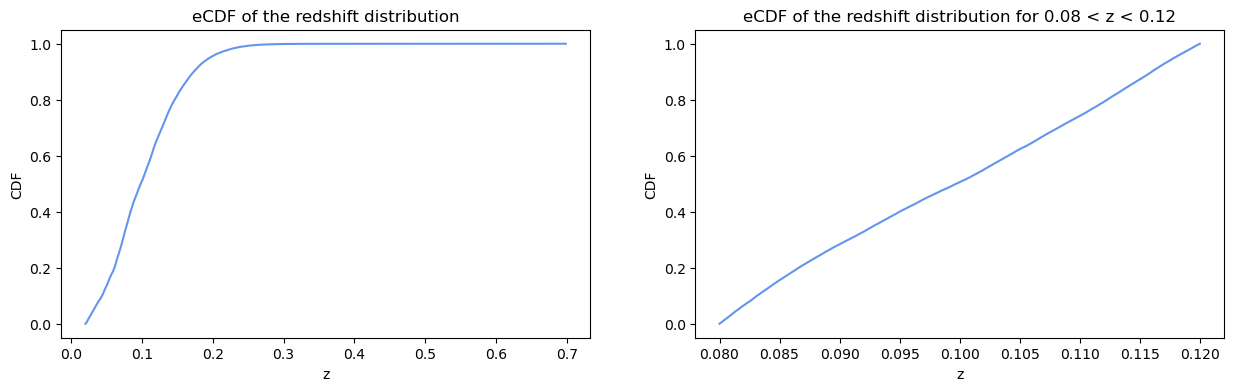

In [4]:
# plot eCDF once for the full sample, then for the selected redshift range

ecdf = ECDF(df_full['Z'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,4))
ax1.step(ecdf.x, ecdf.y, color='cornflowerblue')
ax1.set_xlabel('z')
ax1.set_ylabel('CDF')
ax1.set_title('eCDF of the redshift distribution')

ecdf_cut = ECDF(df['Z'])

ax2.step(ecdf_cut.x, ecdf_cut.y, color='cornflowerblue')
ax2.set_xlabel('z')
ax2.set_ylabel('CDF')
ax2.set_title('eCDF of the redshift distribution for 0.08 < z < 0.12')


Text(0.5, 1.0, 'r-band magnitude vs. redhsift for 0.08 < z < 0.12')

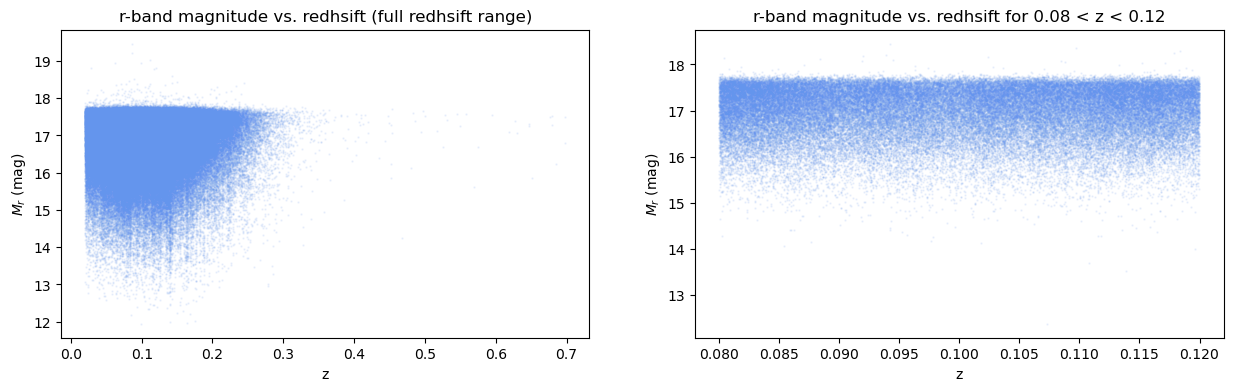

In [5]:
# Scatter plot of r-band magnitude vs. redshift

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,4))

ax1.scatter(df_full['Z'], df_full['phot_r'], s=0.5, alpha=0.1, color='cornflowerblue')
ax1.set_xlabel('z')
ax1.set_ylabel('$M_{r}$ (mag)')
ax1.set_title('r-band magnitude vs. redhsift (full redhsift range)')

ax2.scatter(df['Z'], df['phot_r'], s=0.5, alpha=0.1, color='cornflowerblue')
ax2.set_xlabel('z')
ax2.set_ylabel('$M_{r}$ (mag)')
ax2.set_title('r-band magnitude vs. redhsift for 0.08 < z < 0.12')


**Task 2**

In [6]:
# Devide into red and blue galaxies

df['u_r'] = df['phot_u'] - df['phot_r']
df.loc[df['u_r'] <= 2.3, 'population'] = 'blue'
df.loc[df['u_r'] > 2.3, 'population'] = 'red'
print(df)

                RA        DEC         Z     phot_u     phot_g     phot_r  \
0       130.089951  52.178097  0.080000  19.854843  18.159964  17.345013   
7       130.080073  53.235523  0.080000  19.464210  18.210379  17.555952   
13      130.663027  50.071896  0.080000  20.303741  18.293287  17.320787   
18      131.179422  50.381649  0.080000  19.931213  18.112759  17.150190   
20      131.253821  50.354109  0.080001  19.746584  17.791237  16.751982   
...            ...        ...       ...        ...        ...        ...   
319936  149.619462  46.442470  0.119995  19.849287  18.035412  17.121490   
319941  149.744447  46.309440  0.119997  20.416435  18.376987  17.261572   
319943  149.536604  46.474948  0.119997  18.040950  16.418087  15.617054   
319950  149.777636  47.148649  0.119998  19.260720  17.999435  17.265516   
319955  149.937963  46.482358  0.119999  19.087252  17.185118  16.237055   

           phot_i     phot_z       u_r population  
0       16.930433  16.620535  2.509

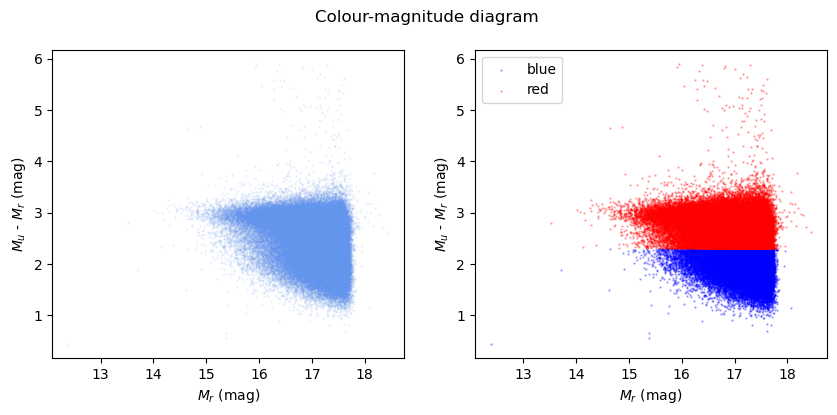

In [7]:
# plot colour-magnitude diagram

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Colour-magnitude diagram')

ax1.scatter(df['phot_r'], df['u_r'], s=0.5, alpha=0.1, color='cornflowerblue')
ax1.set_xlabel('$M_{r}$ (mag)')
ax1.set_ylabel('$M_{u}$ - $M_{r}$ (mag)')


colors = {'red': 'red', 'blue': 'blue'}

for name, group in df.groupby('population'):
    ax2.scatter(group['phot_r'], group['u_r'], c=colors[name], label=name, s=0.5, alpha=0.3)

ax2.set_xlabel('$M_{r}$ (mag)')
ax2.set_ylabel('$M_{u}$ - $M_{r}$ (mag)')
ax2.legend()


**Task 3**

In [ ]:
# create subsamples of red and blue galaxies

df_red = df[df['population'] == 'red']
df_blue = df[df['population'] == 'blue']


                RA        DEC         Z     phot_u     phot_g     phot_r  \
7       130.080073  53.235523  0.080000  19.464210  18.210379  17.555952   
24      131.170686  50.578294  0.080002  18.617350  17.333267  16.722560   
75      130.699722  50.676673  0.080004  19.146296  17.870260  17.223728   
80      130.847669  51.541232  0.080006  18.699663  17.421630  16.798462   
83      130.692557  51.332853  0.080006  19.520935  18.110760  17.450203   
...            ...        ...       ...        ...        ...        ...   
319888  148.584311  46.263574  0.119984  18.629972  17.536009  17.079468   
319911  149.320985  46.691273  0.119987  19.414116  18.026552  17.349916   
319915  149.269252  46.405267  0.119988  19.075863  17.890146  17.306822   
319928  149.306247  47.348096  0.119993  19.784573  18.399982  17.724577   
319950  149.777636  47.148649  0.119998  19.260720  17.999435  17.265516   

           phot_i     phot_z       u_r population  
7       17.136730  16.859112  1.908

In [9]:
# mean and std of the red subsample

r_mean_red = df_red['phot_r'].mean()
r_std_red = df_red['phot_r'].std()
print(r_mean_red, r_std_red)

# mean and std of the blue subsample

r_mean_blue = df_blue['phot_r'].mean()
r_std_blue = df_blue['phot_r'].std()
print(r_mean_blue, r_std_blue)


16.884902132896997 0.5532340973154652
17.148581973026662 0.431767649572343


In [10]:
# bootstrapping 95% confidence interval for mean (red galaxies)

data_red = df_red['phot_r'].dropna().to_numpy()

res_red = bootstrap((data_red,), np.mean, confidence_level=0.95,
                n_resamples=9999, method='basic')


In [11]:
# bootstrapping 95% confidence interval for mean (blue galaxies)

data_blue = df_blue['phot_r'].dropna().to_numpy()

res_blue = bootstrap((data_blue,), np.mean, confidence_level=0.95,
                n_resamples=9999, method='basic')

In [12]:
print(res_red)
print(res_blue)

BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(16.880560330821773), high=np.float64(16.889346253214036)), bootstrap_distribution=array([16.88476741, 16.88093192, 16.88502166, ..., 16.88631971,
       16.88194814, 16.88595512]), standard_error=np.float64(0.00223879588578778))
BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(17.143801286045445), high=np.float64(17.15329505434972)), bootstrap_distribution=array([17.14690797, 17.14186071, 17.15251238, ..., 17.14693335,
       17.15184999, 17.15266987]), standard_error=np.float64(0.0024407951146241643))


In [13]:
# analytic confidence interval for mean (red): 

n_red = len(data_red)
ci_red = stats.t.interval(0.95, df=n_red-1, loc=r_mean_red, scale=r_std_red)
print(ci_red)

# analytic confidence interval for mean (blue): 

n_blue = len(data_blue)
ci_blue = stats.t.interval(0.95, df=n_blue-1, loc=r_mean_blue, scale=r_std_blue)
print(ci_blue)

(np.float64(15.800561589234993), np.float64(17.969242676559))
(np.float64(16.30229929661799), np.float64(17.994864649435335))


**Task 4**

Text(0, 0.5, 'DEC')

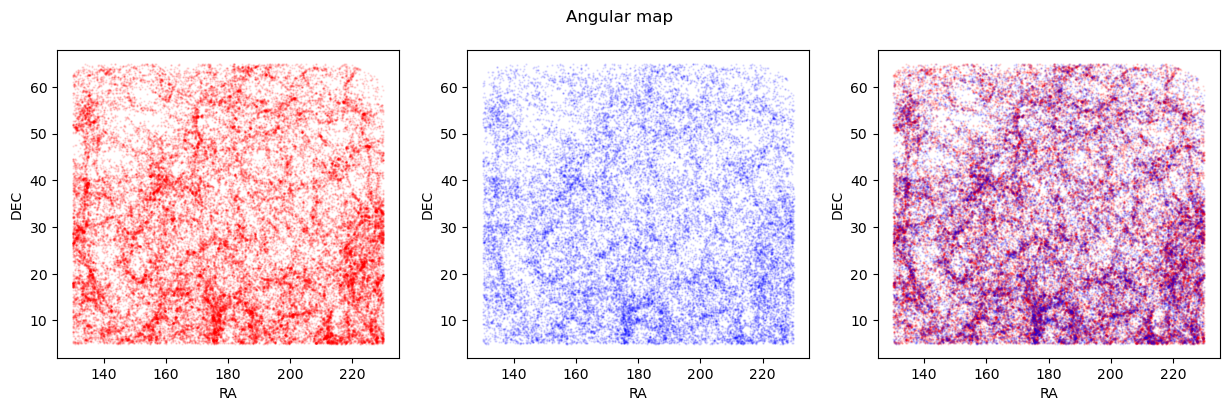

In [14]:
# plot RA vs DEC

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('Angular map')

ax1.scatter(df_red['RA'], df_red['DEC'], s=0.5, alpha=0.1, color='red')
ax2.scatter(df_blue['RA'], df_blue['DEC'], s=0.5, alpha=0.1, color='blue')
ax3.scatter(df_red['RA'], df_red['DEC'], s=0.5, alpha=0.1, color='red')
ax3.scatter(df_blue['RA'], df_blue['DEC'], s=0.5, alpha=0.1, color='blue')


ax1.set_xlabel('RA')
ax1.set_ylabel('DEC')

ax2.set_xlabel('RA')
ax2.set_ylabel('DEC')

ax3.set_xlabel('RA')
ax3.set_ylabel('DEC')

Text(0, 0.5, 'z')

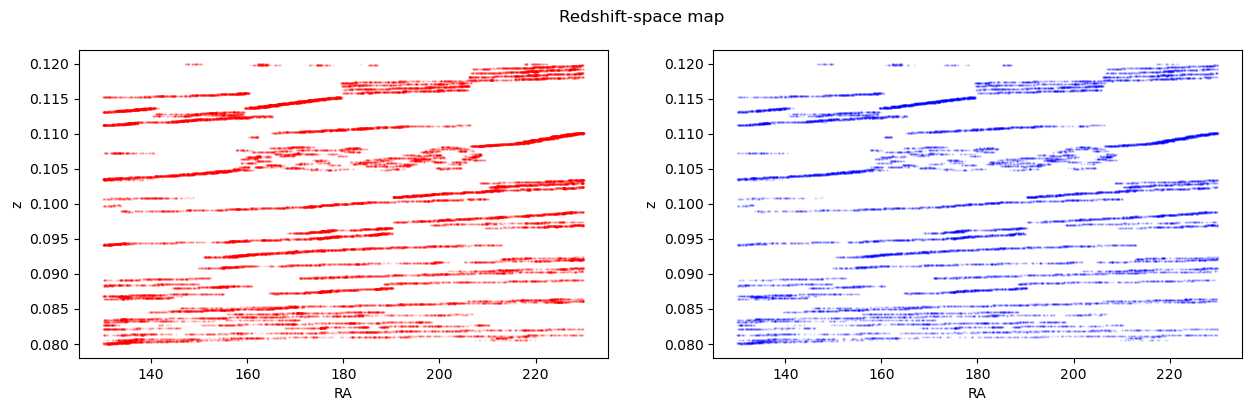

In [ ]:
# plot RA vs redshift

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,4))
fig.suptitle('Redshift-space map')

ax1.scatter(df_red['RA'], df_red['Z'], s=0.5, alpha=0.1, color='red')
ax2.scatter(df_blue['RA'], df_blue['Z'], s=0.5, alpha=0.1, color='blue')

ax1.set_xlabel('RA')
ax1.set_ylabel('z')

ax2.set_xlabel('RA')
ax2.set_ylabel('z')
